# 4.3.1 平衡分支折叠与滞回

## 学习目标与先修知识

能从平衡（equilibrium）方程和零导数（derivative）求折叠点，区分解析分支与有限扫描，比较接续/重启及正反方向，并保留转变区间的分辨率。

先修：第 4.1 章的偏置开关和显式中点法（explicit midpoint method）；导数判据。 [复习上一节](../02-自维持振荡与极限环/02-周期振幅与相位的测量.ipynb)。

## 具体问题

调高刺激后活动突然跳到高状态（state），再调回去却没有沿原路返回，这可能是怎样的机制？先寻找所有平衡，再检查扫描方案是否引入了额外的迟滞。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
fold_x=1/np.sqrt(3)
fold_bias=2/(3*np.sqrt(3))
display(Markdown(show_table(['折叠状态 x','对应 b=x³−x','f′'],[(-fold_x,fold_bias,0),(fold_x,-fold_bias,0)])))

| 折叠状态 x | 对应 b=x³−x | f′ |
| --- | --- | --- |
| -0.57735 | 0.3849 | 0 |
| 0.57735 | -0.3849 | 0 |

## 模型假设

方程为 x′=x−x³+b，x 和 τ 为无量纲（dimensionless）偏差与时间。b 是持续偏置，不是初始刺激。解析图以 x 为自变量画 b=x³−x，包含不稳定分支。

扫描比较 b∈[−0.6,0.6]，网格间隔 0.02，默认每点停留 40；正向起点 x=−1.5，反向 x=1.5，h=0.02。接续方案沿用上一末态；重启方案每点从同一个指定初值（initial condition）重新开始。扫描记录每点停留结束时的状态，并与平衡位置对照。

## 数学解释与推导

平衡满足 b=x³−x。沿这个曲线可以直接标稳定性：f_x=1−3x²，小于零的外侧分支局部吸引，大于零的中间分支排斥。

平衡数目发生改变的位置同时满足 f=0 和 f_x=0：
$$x_*=\pm\frac1{\sqrt3},\qquad b_*=x_*^3-x_*=\mp\frac{2}{3\sqrt3}.$$
在 |b|<2/(3sqrt(3)) 时有三个平衡，在两阈值之外只有一个；在阈值处两个平衡合并，形成鞍结分岔（saddle-node bifurcation）。这里是一维稳定点与不稳定点相遇的标准情形，“鞍结”名称不要求这幅一维图上另画二维鞍点。

可在折叠附近令 x=x*+ξ、b=b*+η，消去常数和线性项，得到 ξ′=η−3x*ξ²−ξ³。二次项及参数（parameter）偏移解释了平衡的产生或消失；只看零导数不能判断临界点本身的两侧流向。

若缓慢增加 b 并沿用状态，轨迹（trajectory）可追踪负侧吸引分支，直到它消失才跳到正侧。反向扫描则沿另一支，形成滞回（hysteresis）：当前参数一样，去向仍依赖过去路径。除此之外，折叠附近速度很小，有限停留可能造成动态延迟（delay）。两者要通过解析分支、延长停留、细化参数网格和时间步分别辨认。

固定初值重启是在问“各个参数下这个起点会去哪里”；接续是在问“沿这条改变过程会去哪里”。起点的选择因此也是扫描方案的一部分。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def switch_step(state,bias,h):
    first=state-state**3+bias
    middle=state+h*first/2
    return state+h*(middle-middle**3+bias)

def scan_bias(biases,initial,h,steps,carry):
    final=[]
    state=initial
    for bias in biases:
        if not carry:state=initial
        for _ in range(steps):state=switch_step(state,bias,h)
        final.append(state)
    return final

def fold_points(a):
    state=math.sqrt(a/3)
    positions=[-state,state]
    return positions,[x**3-a*x for x in positions]

## 对照实验

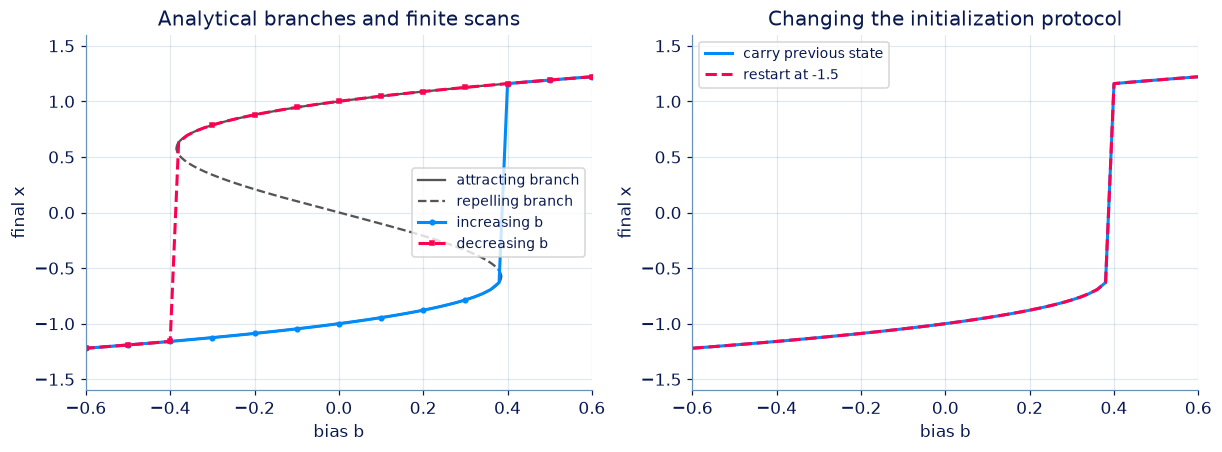

In [4]:
biases=np.linspace(-.6,.6,61)
forward=scan_bias(biases,-1.5,.02,2000,True)
reverse=scan_bias(biases[::-1],1.5,.02,2000,True)
restart=scan_bias(biases,-1.5,.02,2000,False)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for segment,style,label in [(np.linspace(-1.5,-1/np.sqrt(3),180),'-','attracting branch'),(np.linspace(-1/np.sqrt(3),1/np.sqrt(3),180),'--','repelling branch'),(np.linspace(1/np.sqrt(3),1.5,180),'-',None)]:
    axes[0].plot(segment**3-segment,segment,color=GRAY,ls=style,lw=1.5,label=label)
axes[0].plot(biases,forward,color=BLUE,marker='o',markevery=5,ms=3,label='increasing b')
axes[0].plot(biases[::-1],reverse,color=PINK,ls='--',marker='s',markevery=5,ms=3,label='decreasing b')
axes[1].plot(biases,forward,color=BLUE,label='carry previous state')
axes[1].plot(biases,restart,color=PINK,ls='--',label='restart at -1.5')
for ax in axes:
    ax.set(xlabel='bias b',ylabel='final x',xlim=(-.6,.6),ylim=(-1.6,1.6));ax.legend(fontsize=9)
axes[0].set_title('Analytical branches and finite scans')
axes[1].set_title('Changing the initialization protocol')
plt.show()

## 结果解释

左图深灰实线/虚线表示由方程得到的稳定/不稳定平衡，蓝和玫红表示有限扫描结果，二者含义不同。中间不稳定支通常不会被接续积分追踪到。右图比较初始化方案；某些区段在长时间停留后重合，说明两种初始化在那里趋向同一个平衡。

阈值的解析值来自联立方程；扫描只能报告当前参数网格与停留下的转变区间。观察跳跃后，先检查这些控制量，再作机制解释。

### 独立核对

折叠条件由代数核对；数值扫描分别改变时间步和停留，不把两种误差合成一个指标。近临界时差异变大也应保留并解释。

In [5]:
x_fold,b_fold=fold_points(1)
assert np.max(abs(np.array(x_fold)-np.array(x_fold)**3+np.array(b_fold)))<1e-14
assert np.max(abs(1-3*np.array(x_fold)**2))<1e-14
coarse=np.array(forward)
fine=np.array(scan_bias(biases,-1.5,.01,4000,True))
longer=np.array(scan_bias(biases,-1.5,.02,4000,True))
def jump_interval(values):
    index=next(i for i in range(1,len(values)) if values[i-1]<0<=values[i])
    return [float(biases[index-1]),float(biases[index])]
print('原扫描跳变区间',jump_interval(coarse),'半步长',jump_interval(fine),'双停留',jump_interval(longer))
print('半步长最大末态差',np.max(abs(coarse-fine)))
assert np.max(abs(coarse-fine))<.01
assert np.allclose(scan_bias([-0.2,0.2],.3,.01,0,True),[.3,.3])

原扫描跳变区间 [0.38, 0.4] 半步长 [0.38, 0.4] 双停留 [0.38, 0.4]
半步长最大末态差 3.7296221666593965e-10


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-03-分岔与参数变化/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：同时求平衡与零斜率

对 x′=a*x−x³+b，a>0。计算平衡（equilibrium）分支折叠处的状态（state）以及对应偏置。返回按状态从小到大排列的一对结果。

**函数与代码模板**

```python
def solve(
    a: float,
) -> tuple[list[float], list[float]]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 给定正线性系数。 | 1 |

**返回值**

按以下顺序返回元组：(states, biases)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 两个折叠状态，升序。 | 1 |
| `biases` | `list[float]` | 与 states 一一对应的 b，不另外排序。 | 1 |

**计算规则**

由 a−3x²=0 求 x=±sqrt(a/3)，再用平衡关系 b=x³−a*x 求偏置。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 0.1≤a≤3。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 给定正线性系数。 | 3 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 3

result = solve(a)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 两个折叠状态，升序。 | [-1.0, 1.0] | 1 |
| biases | 与 states 一一对应的 b，不另外排序。 | [2.0, -2.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-1.0, 1.0], [2.0, -2.0])
```

**样例解释**

a=3 时折叠状态为 [−1,1]，对应偏置为 [2,−2]；两组数组（array）必须保持配对关系。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同时求平衡与零斜率](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-fold-locations)

### 第 2 题 · Python 计算题：区分重启扫描与接续扫描

对 x′=x−x³+b，按给定顺序逐个使用 biases 中的偏置。每个偏置做相同步数的显式中点积分。

**函数与代码模板**

```python
def solve(
    biases: list[float],
    initial: float,
    h: float,
    steps: int,
    carry: bool,
) -> list[float]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `biases` | `list[float]` | 扫描顺序，不能擅自排序。 | 1 |
| `initial` | `float` | 第一个偏置的起点；重启方案中也是每个偏置的起点。 | 1 |
| `h` | `float` | 时间步长（time step）。 | 1 |
| `steps` | `int` | 每个偏置停留的积分步数。 | 1 |
| `carry` | `bool` | True 沿用上一末态；False 每个偏置都从 initial 重启。 | 1 |

**返回值**

直接返回 final_states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `final_states` | `list[float]` | 每个偏置停留结束后的状态（state）。 | 1 |

**计算规则**

每一步 m=x+h*(x−x³+b)/2，x←x+h*(m−m³+b)。接续时把当前末态作为下一偏置起点；重启时不沿用。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 1≤len(biases)≤40，各值在 [−0.6,0.6]；−1.5≤initial≤1.5；0<h≤0.02；0≤steps≤2000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| biases | 扫描顺序，不能擅自排序。 | [0, 0.4, 0] | 1 |
| initial | 第一个偏置的起点；重启方案中也是每个偏置的起点。 | 0 | 1 |
| h | 时间步长（time step）。 | 0.02 | 1 |
| steps | 每个偏置停留的积分步数。 | 1 | 1 |
| carry | True 沿用上一末态；False 每个偏置都从 initial 重启。 | True | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
biases = [0, 0.4, 0]
initial = 0
h = 0.02
steps = 1
carry = True

result = solve(biases, initial, h, steps, carry)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| final_states | 每个偏置停留结束后的状态（state）。 | [0.0, 0.00807999872, 0.008243203718701131] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 0.00807999872, 0.008243203718701131]
```

**样例解释**

第一个偏置 0 使零初值（initial condition）保持零；偏置 0.4 使状态变正；最后恢复偏置 0 时沿用这个正状态，而非重新设为零。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：区分重启扫描与接续扫描](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-bias-continuation)

### 第 3 题 · 多项选择题：分支图应该标记什么

偏置开关的平衡（equilibrium）关系为 b=x³−x。哪些标记正确？

- **A.** |x|>1/sqrt(3) 的分支局部渐近稳定（local asymptotic stability）。
- **B.** |x|<1/sqrt(3) 的分支不稳定。
- **C.** 在折叠点 f′=0，不能只用一阶导数（derivative）的严格正负判据。
- **D.** 只画接续扫描终点就能找全所有不稳定分支。

[作答：分支图应该标记什么](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-branch-stability)

### 第 4 题 · 单项选择题：为什么正反扫描不重合

正向扫描沿用上一末态，反向也沿用上一末态。某一区间两条结果不同。哪项正确？

- **A.** 可能来自多稳态（multistability）及历史，也可能含有限停留造成的延迟（delay）；需对照分支和停留时间。
- **B.** 足以证明系统受随机噪声驱动。
- **C.** 忽略初值（initial condition）并平均两条曲线，就得到真正唯一平衡（equilibrium）。
- **D.** 必然是程序错误。

[作答：为什么正反扫描不重合](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-scan-protocol)

### 第 5 题 · 单项选择题：转变位置该报告到几位

扫描 b 的间隔是 0.02，观察到状态（state）在 b=0.38 与 0.40 之间跳变，停留时间有限。哪项正确？

- **A.** 阈值精确等于 0.40，最后一位没有误差。
- **B.** 只细化时间步就能消除参数（parameter）网格误差。
- **C.** 阈值精确等于 0.390000。
- **D.** 只报告当前网格与停留条件下的转变区间，并结合解析折叠值和更细实验。

[作答：转变位置该报告到几位](http://127.0.0.1:8000/chapters/04-03-%E5%88%86%E5%B2%94%E4%B8%8E%E5%8F%82%E6%95%B0%E5%8F%98%E5%8C%96/practice/?question=p04-threshold-resolution)